# Importing Necessary Libraries

In [102]:
import pandas as pd
import os
import zipfile
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from sklearn.model_selection import train_test_split
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset,DataLoader
import torch.nn.functional as F

from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Getting the dataset

In [11]:
# check if the data directory is present
os.makedirs("..//data",exist_ok=True)

# download the dataset
os.system(
    "kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge -p ..//data//raw"
)

0

In [ ]:
# unzip the downloaded dataset
with zipfile.ZipFile(
    "..//data//raw//challenges-in-representation-learning-facial-expression-recognition-challenge.zip","r"
) as zip_ref:
    zip_ref.extractall("..//data//raw")

# Explore Data

In [62]:
df = pd.read_csv("..//data//raw//train.csv")
df.head()

,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


(0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral).

In [10]:
class_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

In [5]:
df.iloc[1,0]

np.int64(0)

In [6]:
df.iloc[1,1:].values

array(['151 150 147 155 148 133 111 140 170 174 182 154 153 164 173 178 185 185 189 187 186 193 194 185 183 186 180 173 166 161 147 133 172 151 114 161 161 146 131 104 95 132 163 123 119 129 140 120 151 149 149 153 137 115 129 166 170 181 164 143 157 156 169 179 185 183 186 186 184 190 191 184 186 190 183 175 168 160 147 136 135 167 136 108 153 167 149 137 111 90 134 162 121 122 141 137 151 151 156 143 116 124 159 164 174 169 135 144 155 153 164 170 176 178 177 178 187 185 181 182 183 181 178 170 164 158 148 144 130 136 173 130 97 137 167 157 138 113 90 138 168 109 123 146 151 152 155 127 113 159 167 170 171 142 131 140 154 162 168 169 169 164 168 173 176 179 178 176 173 172 170 161 154 152 146 145 137 124 130 171 124 102 133 164 152 138 110 86 154 149 100 139 153 151 136 113 142 159 161 174 150 127 136 140 154 164 163 167 173 172 171 170 167 168 172 167 162 161 160 163 163 154 145 146 140 133 122 135 167 127 101 126 164 147 132 95 91 166 115 113 158 143 121 134 153 153 164 162 131 130

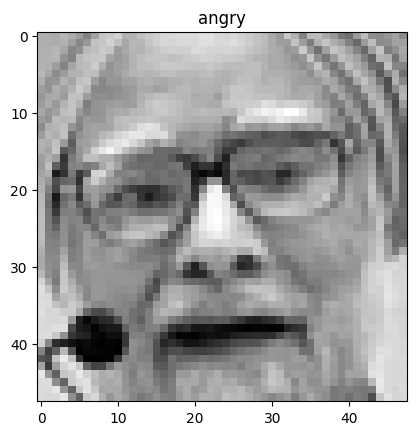

In [7]:
plt.imshow(np.array([float(x) for x in df.iloc[1,1:].values[0].split()]).reshape(48,48),cmap="gray")
plt.title(class_names[df.iloc[1,0]])
plt.show()

# Format the dataset and create new ones

In [75]:
# function to split train into train and validation csv files, while letting test.csv untouched. Only keeping anger, happy and sad emotions and deleting everything else and save the new ones
def preprocess(dataframe):
    classes_to_drop = [1,2,5,6]
    label_mapping = {0:0, 3:1, 4:2}
    dataframe = dataframe[~dataframe["emotion"].isin(classes_to_drop)]
    dataframe["emotion"] = dataframe["emotion"].map(label_mapping)
    dataframe['pixels'] = dataframe['pixels'].str.split().apply(lambda x: np.array([float(i) for i in x], dtype=np.float32))
    train_dataframe, test_dataframe = train_test_split(dataframe,test_size=0.20,stratify=dataframe["emotion"],random_state=42)
    train_dataframe, validation_dataframe = train_test_split(train_dataframe,test_size=0.20,stratify=train_dataframe["emotion"],random_state=42)
    return train_dataframe,validation_dataframe,test_dataframe

In [76]:
dataframe = pd.read_csv("..//data//raw//train.csv")
train_dataframe, validation_dataframe, test_dataframe = preprocess(dataframe)

In [105]:
class_labels = {0:"Angry",1:"Happy",2:"Sad"}
class_labels

{0: 'Angry', 1: 'Happy', 2: 'Sad'}

In [109]:
emotion_count_train, emotion_count_validation, emotion_count_test = train_dataframe['emotion'].value_counts().sort_index(), validation_dataframe['emotion'].value_counts().sort_index(), test_dataframe['emotion'].value_counts().sort_index()
print(f"Emotion Counts in Train Data: {emotion_count_train}, \nEmotion Counts in Validation Data: {emotion_count_validation}, \nEmotion Counts in Test Data: {emotion_count_test}")

Emotion Counts in Train Data: emotion
0    2557
1    4617
2    3091
Name: count, dtype: int64, 
Emotion Counts in Validation Data: emotion
0     639
1    1155
2     773
Name: count, dtype: int64, 
Emotion Counts in Test Data: emotion
0     799
1    1443
2     966
Name: count, dtype: int64


In [106]:
labels = [class_labels[i] for i in emotion_count_train.index]
labels

['Angry', 'Happy', 'Sad']

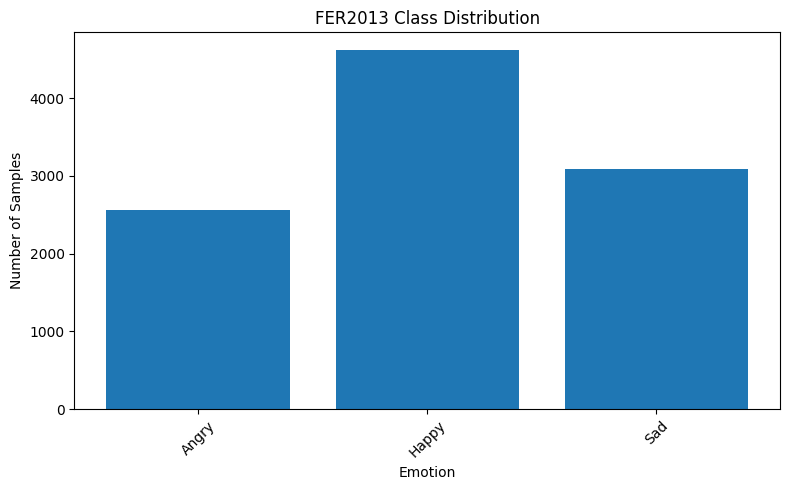

In [110]:
plt.figure(figsize=(8,5))
plt.bar(labels, emotion_count_train.values)
plt.title("FER2013 Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [78]:
len(train_dataframe),len(validation_dataframe),len(test_dataframe)

(10265, 2567, 3208)

In [79]:
os.makedirs("..//data//processed",exist_ok=True)
train_dataframe.to_pickle("..//data//processed//train.pkl")
validation_dataframe.to_pickle("..//data//processed//validation.pkl")
test_dataframe.to_pickle("..//data//processed//test.pkl")

# Setup Dataset and Dataloader along with transforms

In [76]:
train_dataframe = pd.read_pickle("..//data//processed//train.pkl")
validation_dataframe = pd.read_pickle("..//data//processed//validation.pkl")
test_dataframe = pd.read_pickle("..//data//processed//test.pkl")

#### Custom Dataset Class

In [77]:
class emotionDataset(Dataset):
    def __init__(self,dataframe,transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        
        self.emotions = self.dataframe['emotion'] 
        self.pixels = self.dataframe['pixels']        
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, index):
        label = self.emotions.iloc[index]
        features = self.pixels.iloc[index]
        
        feature_matrix = features.reshape(48,48).astype(np.uint8)
        image = Image.fromarray(feature_matrix,mode='L')
        
        label = torch.tensor(label,dtype=torch.long)
        
        if self.transform:
            image = self.transform(image)
        else:
            default_transform = torch.ToTensor()
            image = default_transform(image)
        
        return  image,label

#### Applying Transformations to Dataset

In [78]:
def mean_std_calculator(dataframe):
    all_pixels = np.vstack(dataframe['pixels'].values)
    scaled_pixels = all_pixels / 255.0
    dataset_mean = float(np.mean(scaled_pixels))
    dataset_std = float(np.std(scaled_pixels))
    return dataset_mean, dataset_std

In [79]:
train_dataset_mean, train_dataset_std = mean_std_calculator(train_dataframe)
validation_dataset_mean, validation_dataset_std =  mean_std_calculator(validation_dataframe)
test_dataset_mean, test_dataset_std = mean_std_calculator(test_dataframe)
print(f"Dataset Mean: {(train_dataset_mean+validation_dataset_mean+test_dataset_mean)/3.0:.4f} | Dataset Standard Deviation: {(test_dataset_std+validation_dataset_std+test_dataset_std)/3.0:.4f}")

Dataset Mean: 0.4952 | Dataset Standard Deviation: 0.2534


In [80]:
transform = transforms.Compose([
    # transforms.RandomHorizontalFlip(p=0.5),
    # transforms.RandomRotation(degrees=15),
    # transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4952],std=[0.2534])
])

In [81]:
train_dataset = emotionDataset(train_dataframe,transform=transform)
validation_dataset = emotionDataset(validation_dataframe,transform=transform)
test_dataset = emotionDataset(test_dataframe,transform=transform)

#### DataLoaders

In [82]:
train_dataloader = DataLoader(train_dataset,batch_size=32,shuffle=True,drop_last=True)
validation_dataloader = DataLoader(validation_dataset,batch_size=32,shuffle=False)
test_dataloader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [83]:
train_dataloader

In [84]:
images_batch, labels_batch = next(iter(train_dataloader))

print("====== DATALOADER SANITY CHECK ======")
print(f"Images Shape:  {images_batch.shape}")  
print(f"Labels Shape:  {labels_batch.shape}")  
print(f"Images Dtype:  {images_batch.dtype}")  
print(f"Labels Dtype:  {labels_batch.dtype}")  
print(f"Value Range:   Min = {images_batch.min().item():.2f}, Max = {images_batch.max().item():.2f}")
print(f"Unique Labels: {labels_batch.unique().tolist()}")


====== DATALOADER SANITY CHECK ======
Images Shape:  torch.Size([32, 1, 48, 48])
Labels Shape:  torch.Size([32])
Images Dtype:  torch.float32
Labels Dtype:  torch.int64
Value Range:   Min = -1.95, Max = 1.99
Unique Labels: [0, 1, 2]


# Setting up device agnostic code

In [85]:
device = torch.device('cuda' if torch.cuda.is_available else 'cpu')
device

device(type='cuda')

# Building CNN Model

In [86]:
class residualBlock(nn.Module):
    def __init__(self,in_channels,out_channels,dropout_prob=0.4):
        super(residualBlock,self).__init__()
        self.conv1 = nn.Conv2d(in_channels,out_channels,kernel_size=3,stride=1,padding=1,bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels,out_channels,kernel_size=3,stride=1,padding=1,bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        self.drop = nn.Dropout(dropout_prob)
    
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        out+=self.shortcut(x)
        out = F.relu(out)
        out = self.drop(out)
        return out

In [87]:
class emotionModel(nn.Module):
    def __init__(self,num_classes=3):
        super(emotionModel,self).__init__()
        # Initial conv layer
        self.init_conv = nn.Sequential(
            nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,stride=1,padding=1,bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        
        # Block 1
        self.block1 = residualBlock(in_channels=32,out_channels=32,dropout_prob=0.4)
        
        # Block 2
        self.block2 = residualBlock(in_channels=32,out_channels=64,dropout_prob=0.4)
        
        # Block 3
        self.block3 = residualBlock(in_channels=64,out_channels=128,dropout_prob=0.4)
        
        # for Downsampling
        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)
        
        # global average pooling
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        
        # classifier
        self.fc = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(128,num_classes)
        )
        
    def forward(self,x):
        x = self.init_conv(x)
        
        x = self.block1(x)
        x = self.pool(x)
        
        x = self.block2(x)
        x = self.pool(x)
        
        x = self.block3(x)
        
        x = self.gap(x)
        x = torch.flatten(x,1)
        x = self.fc(x)
        
        return x

In [88]:
model = emotionModel(num_classes=3).to(device)
print(model)

emotionModel(
  (init_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (block1): residualBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (shortcut): Sequential()
    (drop): Dropout(p=0.4, inplace=False)
  )
  (block2): residualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3

# Setting up loss function and optimizer
For our usecase, since our data is mildly imbalanced (~1:2:1) we'll use weighted cross-entropy loss 

In [89]:
def calculate_weights(total_samples,samples_in_class,classes):
    for i in range(len(classes)):
        classes[i] = total_samples / (len(classes)*samples_in_class[i])
    return classes

In [90]:
classes = [0,1,2]
total_samples = len(train_dataset)
samples_in_class = [i for i in train_dataframe["emotion"].value_counts().sort_index().values]
class_weights = calculate_weights(total_samples,samples_in_class,classes)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
class_weights

tensor([1.3382, 0.7411, 1.1070], device='cuda:0')

In [91]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-3)

# Training and Validation Loop

In [92]:
os.makedirs("..//model",exist_ok=True)

In [93]:
epochs = 100
train_loss,train_acc,validation_loss,validation_acc = [],[],[],[]
best_val_f1 = 0.0

print(f"Starting Model training pipeline on hardware device: {device}\n")

for epoch in range(epochs):
    # ====================TRAINING PHASE====================
    model.train()
    running_training_loss = 0.0
    correct_train = 0.0
    for images,labels in train_dataloader:      
        images,labels = images.to(device),labels.to(device)
        
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output,labels) 
        
        loss.backward()
        optimizer.step()
        
        running_training_loss += loss.item() * images.size(0)
        
        _,preds = torch.max(output,1)
        correct_train += (preds==labels).sum().item()
        
    epoch_train_loss = running_training_loss / len(train_dataloader.dataset)
    epoch_train_acc = (correct_train/len(train_dataloader.dataset)) * 100
    
    # ====================VALIDATION PHASE====================
    model.eval()
    running_validation_loss = 0.0
    correct_val = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for val_images,val_labels in validation_dataloader:
            val_images,val_labels = val_images.to(device), val_labels.to(device)
            
            val_output = model(val_images)
            val_loss = criterion(val_output,val_labels)
            
            running_validation_loss += val_loss.item() * val_images.size(0)
            
            _,val_preds = torch.max(val_output,1)
            correct_val += (val_preds==val_labels).sum().item()

            all_preds.extend(val_preds.cpu().numpy())
            all_labels.extend(val_labels.cpu().numpy())
            
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        
        epoch_validation_loss = running_validation_loss / len(validation_dataloader.dataset)
        epoch_validation_acc = (correct_val/len(validation_dataloader.dataset)) * 100
        epoch_validation_f1 = f1_score(all_labels,all_preds,average="macro")
            
    train_loss.append(epoch_train_loss)
    train_acc.append(epoch_train_acc)
    validation_loss.append(epoch_validation_loss)
    validation_acc.append(epoch_validation_acc)        
    
    print(f'Epoch [{epoch + 1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Train Accuracy: {epoch_train_acc:.2f}% | Validation Loss: {epoch_validation_loss:.4f} | Validation Accuracy: {epoch_validation_acc:.2f}% | Validation F1 Score: {epoch_validation_f1}')

    if epoch_validation_f1 > best_val_f1:
        best_val_f1 = epoch_validation_f1
        torch.save(model.state_dict(),"..//model//best_emotion_model.pth")  
        print("New best f1 score achieved. Saving model's weights.")
    print("-"*50)
    
print("\nTRAINING COMPLETE.")

Starting Model training pipeline on hardware device: cuda

Epoch [1/100] | Train Loss: 1.1052 | Train Accuracy: 40.01% | Validation Loss: 1.0808 | Validation Accuracy: 44.29% | Validation F1 Score: 0.3644228947411527
New best f1 score achieved. Saving model's weights.
--------------------------------------------------
Epoch [2/100] | Train Loss: 1.0293 | Train Accuracy: 47.66% | Validation Loss: 1.1172 | Validation Accuracy: 37.79% | Validation F1 Score: 0.26182603318991016
--------------------------------------------------
Epoch [3/100] | Train Loss: 0.8890 | Train Accuracy: 58.86% | Validation Loss: 0.9570 | Validation Accuracy: 56.33% | Validation F1 Score: 0.43448099284544517
New best f1 score achieved. Saving model's weights.
--------------------------------------------------
Epoch [4/100] | Train Loss: 0.7980 | Train Accuracy: 65.07% | Validation Loss: 0.9032 | Validation Accuracy: 61.12% | Validation F1 Score: 0.48478630492074054
New best f1 score achieved. Saving model's weight

# Evaluate (on test dataset) and plot graphs

In [95]:
best_model = emotionModel(num_classes=3)
best_model.load_state_dict(torch.load("..//model//best_emotion_model.pth",map_location=device))

<All keys matched successfully>

In [98]:
best_model.to(device)

emotionModel(
  (init_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (block1): residualBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (shortcut): Sequential()
    (drop): Dropout(p=0.4, inplace=False)
  )
  (block2): residualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3

In [100]:
all_test_preds, all_test_labels = [], []
print("Evaluating Model on the unseen test data...")
best_model.eval()
test_loss = 0.0
correct_test = 0.0
with torch.no_grad():
    for test_images,test_labels in test_dataloader:
        test_images,test_labels = test_images.to(device),test_labels.to(device)
        
        test_outputs = best_model(test_images)
        loss = criterion(test_outputs,test_labels)
        
        test_loss += loss.item() * test_images.size(0)
        
        _, preds = torch.max(test_outputs,1)
        correct_test += (preds==test_labels).sum().item()
        
        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(test_labels.cpu().numpy())

test_loss = test_loss / len(test_dataloader.dataset)
test_acc = (correct_test/len(test_dataloader.dataset)) * 100
test_preds = np.array(all_test_preds)
test_labels = np.array(all_test_labels)

print(f"Evaluation on unseen test data done.\nFinal Test Loss: {test_loss} | Final Test Accuracy: {test_acc}")

Evaluating Model on the unseen test data...
Evaluation on unseen test data done.
Final Test Loss: 0.5741438213131969 | Final Test Accuracy: 78.27306733167082


In [103]:
print("\n" + "="*20 + " FINAL TEST PERFORMANCE " + "="*20)
print(classification_report(all_test_labels, all_test_preds, target_names=['Class 0', 'Class 1', 'Class 2']))

print("\n"+"="*25 + " CONFUSION MATRIX " + "="*25)
print(confusion_matrix(all_test_labels, all_test_preds))


==================== FINAL TEST PERFORMANCE ====================
              precision    recall  f1-score   support

     Class 0       0.65      0.72      0.68       799
     Class 1       0.91      0.88      0.89      1443
     Class 2       0.72      0.70      0.71       966

    accuracy                           0.78      3208
   macro avg       0.76      0.76      0.76      3208
weighted avg       0.79      0.78      0.78      3208


========================= CONFUSION MATRIX =========================
[[ 573   60  166]
 [  80 1263  100]
 [ 233   58  675]]
